Find best knots

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from patsy import dmatrix
import statsmodels.api as sm
import itertools
from tqdm import tqdm

X2009data = pd.read_csv("/Users/zhanghaobo/Documents/GitHub/demos_v_matrix/COPD/CDC_data/2009_2012_data.csv")

# Subset by gender
male_data = X2009data[X2009data["Gender"] == 1].copy()
female_data = X2009data[X2009data["Gender"] == 2].copy()

# Convert Race to category
male_data["Race"] = male_data["Race"].astype("category")
female_data["Race"] = female_data["Race"].astype("category")

# Generate knot pairs
knot_pairs = list(itertools.combinations(range(10, 26), 2))
AIC_lists = []

# Fit FEV_1 model for males and get best knots by AIC
for knots in knot_pairs:
    spline = dmatrix(f"cr(Age_in_years, knots={knots})", male_data, return_type='dataframe')
    X = pd.concat([
        sm.add_constant(male_data[["BMI", "Height_cm", "smoking_years"]]),
        male_data["BMI"]**2,
        male_data["Height_cm"]**2,
        spline
    ], axis=1)
    
    model = sm.GLM(male_data["FEV_1"], X).fit()
    AIC_lists.append(model.aic)
best_knots_FEV_male = knot_pairs[np.argmin(AIC_lists)]
print("Best knot pair for FEV (male):", best_knots_FEV_male)

# Repeat for FVC (male)
AIC_lists = []
for knots in knot_pairs:
    spline = dmatrix(f"cr(Age_in_years, knots={knots})", male_data, return_type='dataframe')
    X = pd.concat([
        sm.add_constant(male_data[["BMI", "Height_cm", "smoking_years"]]),
        male_data["BMI"]**2,
        male_data["Height_cm"]**2,
        spline
    ], axis=1)
    model = sm.GLM(male_data["FVC"], X).fit()
    AIC_lists.append(model.aic)

best_knots_FVC_male = knot_pairs[np.argmin(AIC_lists)]
print("Best knot pair for FVC (male):", best_knots_FVC_male)

# Repeat for FEV_1 (female)
AIC_lists = []
for knots in knot_pairs:
    spline = dmatrix(f"cr(Age_in_years, knots={knots})", female_data, return_type='dataframe')
    X = pd.concat([
        sm.add_constant(female_data[["BMI", "Height_cm", "smoking_years"]]),
        female_data["BMI"]**2,
        female_data["Height_cm"]**2,
        spline
    ], axis=1)
    model = sm.GLM(female_data["FEV_1"], X).fit()
    AIC_lists.append(model.aic)

best_knots_FEV_female = knot_pairs[np.argmin(AIC_lists)]
print("Best knot pair for FEV (female):", best_knots_FEV_female)

# Repeat for FVC (female)
AIC_lists = []
for knots in knot_pairs:
    spline = dmatrix(f"cr(Age_in_years, knots={knots})", female_data, return_type='dataframe')
    X = pd.concat([
        sm.add_constant(female_data[["BMI", "Height_cm", "smoking_years"]]),
        female_data["BMI"]**2,
        female_data["Height_cm"]**2,
        spline
    ], axis=1)
    model = sm.GLM(female_data["FVC"], X).fit()
    AIC_lists.append(model.aic)

best_knots_FVC_female = knot_pairs[np.argmin(AIC_lists)]
print("Best knot pair for FVC (female):", best_knots_FVC_female)


Best knot pair for FEV (male): (22, 24)
Best knot pair for FVC (male): (24, 25)
Best knot pair for FEV (female): (18, 25)
Best knot pair for FVC (female): (24, 25)


Build models

In [52]:
spline_FEV_male = dmatrix(f"cr(Age_in_years, knots={best_knots_FEV_male})", male_data, return_type='dataframe')
spline_FVC_male = dmatrix(f"cr(Age_in_years, knots={best_knots_FVC_male})", male_data, return_type='dataframe')
spline_FEV_female = dmatrix(f"cr(Age_in_years, knots={best_knots_FEV_female})", female_data, return_type='dataframe')
spline_FVC_female = dmatrix(f"cr(Age_in_years, knots={best_knots_FVC_female})", female_data, return_type='dataframe')

X_FEV_male = pd.concat([
        sm.add_constant(male_data[["BMI", "Height_cm", "smoking_years"]]),
        male_data["BMI"]**2,
        male_data["Height_cm"]**2,
        spline_FEV_male
    ], axis=1)

X_FVC_male = pd.concat([
        sm.add_constant(male_data[["BMI", "Height_cm", "smoking_years"]]),
        male_data["BMI"]**2,
        male_data["Height_cm"]**2,
        spline_FVC_male
    ], axis=1)

X_FEV_female = pd.concat([
        sm.add_constant(female_data[["BMI", "Height_cm", "smoking_years"]]),
        female_data["BMI"]**2,
        female_data["Height_cm"]**2,
        spline_FEV_female
    ], axis=1)

X_FVC_female = pd.concat([
        sm.add_constant(female_data[["BMI", "Height_cm", "smoking_years"]]),
        female_data["BMI"]**2,
        female_data["Height_cm"]**2,
        spline_FVC_female
    ], axis=1)

model_FEV_male = sm.GLM(male_data["FEV_1"], X_FEV_male).fit()
model_FVC_male = sm.GLM(male_data["FVC"], X_FVC_male).fit()
model_FEV_female = sm.GLM(female_data["FEV_1"], X_FEV_female).fit()
model_FVC_female = sm.GLM(female_data["FVC"], X_FVC_female).fit()

View the results

const                                  2399.613480
BMI                                      62.299879
Height_cm                               -75.060482
smoking_years                            -7.931845
BMI                                      -1.093159
Height_cm                                 0.336802
Intercept                              2399.613480
cr(Age_in_years, knots=(22, 24))[0]    -188.081504
cr(Age_in_years, knots=(22, 24))[1]    1416.903039
cr(Age_in_years, knots=(22, 24))[2]    1385.171181
cr(Age_in_years, knots=(22, 24))[3]    -214.379236
dtype: float64
    const   BMI  Height_cm  smoking_years      BMI  Height_cm  Intercept  \
0       1  36.8      162.1           47.0  1354.24   26276.41        1.0   
1       1  36.8      162.1           47.0  1354.24   26276.41        1.0   
2       1  36.8      162.1           47.0  1354.24   26276.41        1.0   
3       1  36.8      162.1           47.0  1354.24   26276.41        1.0   
4       1  36.8      162.1           47.0  1

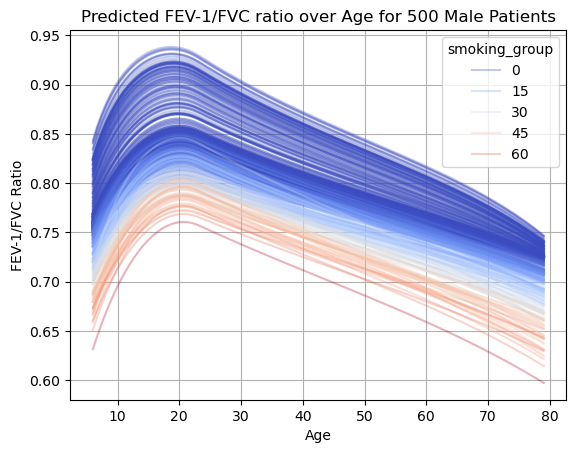

In [ ]:
age_seq = np.linspace(X2009data["Age_in_years"].min(), X2009data["Age_in_years"].max(), 100)

lines = []

for i in range(500):
    row = male_data.sample(1).iloc[0]

    new_df = pd.DataFrame({
        "const": 1,
        "Age_in_years": age_seq,
        "BMI": row["BMI"],
        "Height_cm": row["Height_cm"],
        "smoking_years": row["smoking_years"],
    })

    spline = dmatrix(f"cr(Age_in_years, knots={best_knots_FEV_male})", new_df, return_type='dataframe')

    X_pred = pd.concat([
        sm.add_constant(new_df[["const", "BMI", "Height_cm", "smoking_years"]]),
        new_df["BMI"]**2,
        new_df["Height_cm"]**2,
        spline
    ], axis=1)

    new_df["FEV_prediction"] = model_FEV_male.predict(X_pred)
    new_df["FVC_prediction"] = model_FVC_male.predict(X_pred)
    new_df["ratio_prediction"] = model_FEV_male.predict(X_pred)/model_FVC_male.predict(X_pred)
    new_df["line_id"] = i
    new_df["smoking_group"] = row["smoking_years"]
    lines.append(new_df)


result = pd.concat(lines)

sns.lineplot(data=result, x="Age_in_years", y="ratio_prediction", hue="smoking_group",
             units="line_id", estimator=None, alpha=0.3, palette="coolwarm")
plt.title("Predicted FEV-1/FVC ratio over Age for 500 Male Patients")
plt.xlabel("Age")
plt.ylabel("FEV-1/FVC Ratio")
plt.grid(True)
plt.show()

